# Road Accident Prediction in India (Regression Analysis)

##  Problem Statement

Road accidents remain a major public safety concern in India, leading to significant loss of life and economic damage every year. Understanding accident patterns and predicting future accident counts can help policymakers, transport authorities, and planners make informed decisions.

This project aims to build a Machine Learning Regression model to predict the number of road accidents for each State/Union Territory in India using historical data from 2016 to 2022.

---

## Objective

- To analyze historical road accident data (state-wise and year-wise).
- To build and compare multiple regression models:
  - Linear Regression
  - K-Nearest Neighbors (KNN)
  - Support Vector Machine (SVM)
  - Decision Tree
- To evaluate models using:
  - R² Score
  - Mean Absolute Error (MAE)
  - Root Mean Squared Error (RMSE)
- To select the best-performing model.
- To use the selected model to predict road accident counts for the year 2023.

---

## Target Variable

- **Accidents_clean** → Total number of road accidents (continuous variable).

---

## Features Used

- Year
- Accidents_prev (Previous year accidents)
- Acc_Per_Lakh_Pop (Accidents per lakh population)
- Acc_Per_10k_Veh (Accidents per 10,000 vehicles)
- Acc_Per_10k_Km (Accidents per 10,000 km road length)
- State-wise encoded variables

---

## Expected Outcome

The final model will provide:

- Accurate state-wise accident predictions.
- Insight into factors influencing road accident trends.
- A forecast of road accidents for 2023 based on historical patterns.

---

## Project Scope

This is a supervised learning regression problem where the goal is to predict a continuous numeric outcome using structured historical data.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [2]:
df = pd.read_csv("road_accidents_preprocessed.csv")

print("Shape:", df.shape)
df.head()

Shape: (175, 42)


,Year,Accidents_clean,Accidents_prev,Acc_Per_Lakh_Pop,Acc_Per_10k_Veh,Acc_Per_10k_Km,State_UT_encoded,State_UT_Andhra Pradesh,State_UT_Arunachal Pradesh,State_UT_Assam,...,State_UT_Puducherry,State_UT_Punjab,State_UT_Rajasthan,State_UT_Sikkim,State_UT_Tamil Nadu,State_UT_Telangana,State_UT_Tripura,State_UT_Uttar Pradesh,State_UT_Uttarakhand,State_UT_West Bengal
0,2016,238.0,234.0,43.190,21.42,1594.32,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2017,189.0,238.0,33.570,15.55,1168.92,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2018,254.0,189.0,44.170,19.37,1415.83,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2019,230.0,254.0,39.120,16.31,1415.83,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2022,141.0,230.0,41.155,17.84,1415.83,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Prepare Features & Target

In [3]:
X = df.drop(columns=['Accidents_clean'])
y = df['Accidents_clean']

In [4]:
if 'State_UT_encoded' in X.columns:
    X = X.drop(columns=['State_UT_encoded'])

Train-Test Split

In [5]:
train = df[df['Year'] <= 2020]
test = df[df['Year'] > 2020]

X_train = train.drop(columns=['Accidents_clean'])
y_train = train['Accidents_clean']

X_test = test.drop(columns=['Accidents_clean'])
y_test = test['Accidents_clean']

Scaling (for KNN & SVM)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

KNN

In [8]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

SVM

In [9]:
svr = SVR()
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

Decision Tree

In [10]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Compare Models

In [11]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("R2:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_knn, "KNN")
evaluate(y_test, y_pred_svr, "SVM")
evaluate(y_test, y_pred_dt, "Decision Tree")


Linear Regression
R2: 0.9928746900866624
MAE: 939.3836509695894
RMSE: 1452.0373073332332

KNN
R2: 0.922595531914989
MAE: 2918.2742857142853
RMSE: 4785.848106717494

SVM
R2: -0.16573013930264002
MAE: 12188.10665741173
RMSE: 18572.69419928681

Decision Tree
R2: 0.9878450382434896
MAE: 988.1714285714286
RMSE: 1896.4993314751562


Select model with:

- Highest R2
- Lowest RMSE

In [12]:
data_2022 = df[df['Year'] == 2022].copy()

In [13]:
data_2023 = data_2022.copy()

data_2023['Year'] = 2023

# Previous accidents for 2023 = 2022 accidents
data_2023['Accidents_prev'] = data_2022['Accidents_clean']

In [14]:
X_2023 = data_2023.drop(columns=['Accidents_clean'])

In [15]:
pred_2023 = lr.predict(X_2023)

data_2023['Predicted_Accidents_2023'] = pred_2023



data_2023[['Predicted_Accidents_2023']].head()

,Predicted_Accidents_2023
4,352.779496
9,23942.951614
14,332.795600
19,7922.159816
24,9883.259890


In [16]:

data_2022 = df[df['Year'] == 2022].copy()

# Create 2023 dataset
data_2023 = data_2022.copy()
data_2023['Year'] = 2023

# For 2023, previous accidents = 2022 accidents
data_2023['Accidents_prev'] = data_2022['Accidents_clean']

# Prepare features
X_2023 = data_2023.drop(columns=['Accidents_clean'])

# Make sure column order matches training data
X_2023 = X_2023[X_train.columns]

# Predict
pred_2023 = lr.predict(X_2023)

# Add predictions to dataframe
data_2023['Predicted_Accidents_2023'] = pred_2023.round(0)

# Extract State Name from one-hot columns
state_cols = [
    col for col in data_2023.columns
    if col.startswith("State_UT_") and col != "State_UT_encoded"
]

data_2023['State_Name'] = (
    data_2023[state_cols]
    .idxmax(axis=1)
    .str.replace("State_UT_", "", regex=False)
)

# Final Clean Output
final_2023_prediction = data_2023[['State_Name', 'Predicted_Accidents_2023']]

# Sort by highest accidents
final_2023_prediction = final_2023_prediction.sort_values(
    by='Predicted_Accidents_2023',
    ascending=False
)

print("Predicted Road Accidents for 2023 : State-wise")
print(final_2023_prediction.to_string(index=False))

Predicted Road Accidents for 2023 : State-wise
                              State_Name  Predicted_Accidents_2023
                              Tamil Nadu                   64576.0
                          Madhya Pradesh                   52396.0
                               Karnataka                   41829.0
                                  Kerala                   40658.0
                           Uttar Pradesh                   40387.0
                             Maharashtra                   35881.0
                          Andhra Pradesh                   23943.0
                               Rajasthan                   23044.0
                               Telangana                   22300.0
                                 Gujarat                   18657.0
                            Chhattisgarh                   13782.0
                             West Bengal                   12258.0
                                 Haryana                   11371.0
               

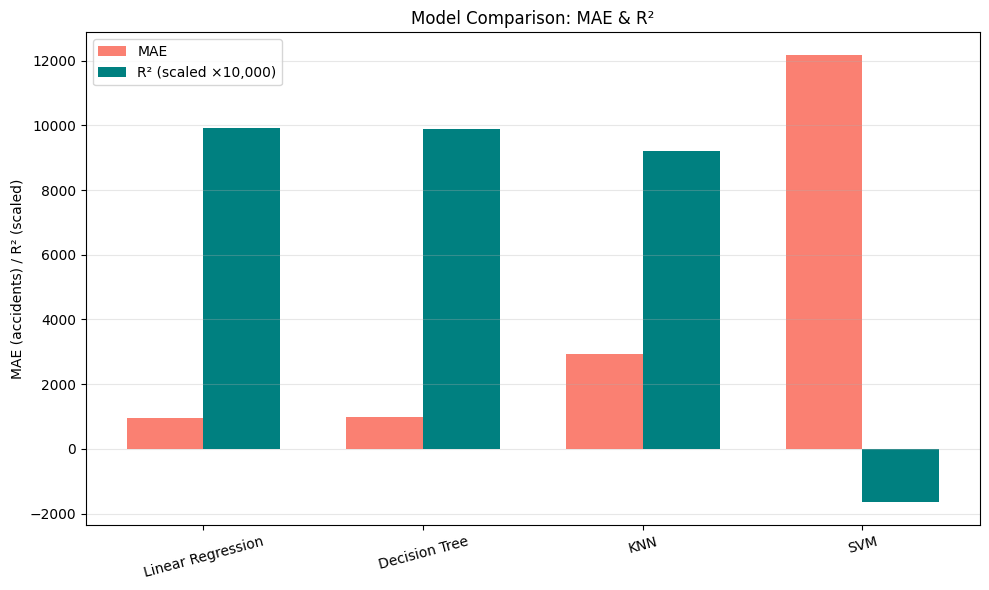

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Your actual results
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN', 'SVM', 'Decision Tree'],
    'R2': [0.9928746900866624, 0.922595531914989, -0.16573013930264002, 0.9878450382434896],
    'MAE': [939.3836509695894, 2918.2742857142853, 12188.10665741173, 988.1714285714286],
    'RMSE': [1452.0373073332332, 4785.848106717494, 18572.69419928681, 1896.4993314751562]
}).sort_values('R2', ascending=False)

plt.figure(figsize=(10, 6))

x = range(len(results_df))
width = 0.35

plt.bar([i - width/2 for i in x], results_df['MAE'], width, label='MAE', color='salmon')
plt.bar([i + width/2 for i in x], results_df['R2'] * 10000, width, label='R² (scaled ×10,000)', color='teal')

plt.xticks(x, results_df['Model'], rotation=15)
plt.ylabel('MAE (accidents) / R² (scaled)')
plt.title('Model Comparison: MAE & R²')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("regression_model_comparison_updated.png", dpi=300, bbox_inches='tight')
plt.show()